# Customer Segmentation

## Project Overview
This project analyzes customer data to identify meaningful customer segments based on behavioral and transactional patterns.  
The workflow includes data cleaning, exploratory data analysis (EDA), feature preparation, clustering, and business interpretation.

## Objective
The goal is to group customers into distinct segments using clustering techniques and to interpret these segments in a way that supports business decision-making.

## Dataset Description
The dataset contains customer-level information such as:
- age
- annual income
- spending score
- tenure in months
- purchase frequency
- average order value
- product category preference
- region
- online activity score
- loyalty membership

The aim is to use these features to discover natural customer groups.

## Data Loading and Initial Inspection

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/customer_segmentation_raw.csv')
df.head()

,customer_id,age,annual_income,spending_score,tenure_months,purchase_frequency,avg_order_value,product_category_preference,region,online_activity_score,loyalty_member
0,SEG0001,23,69952.22,61,1,3.8,157.75,Electronics,East,9,Yes
1,SEG0002,30,43946.07,91,23,3.7,65.76,Electronics,West,69,Yes
2,SEG0003,59,91362.15,77,32,7.0,151.65,Home,NaN,39,Yes
3,SEG0004,47,38542.28,33,12,5.8,24.49,Electronics,West,22,No
4,SEG0005,18,39402.21,75,22,5.2,121.15,Sports,East,40,Yes


## Initial Data Inspection

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (266, 11)

Columns:
['customer_id', 'age', 'annual_income', 'spending_score', 'tenure_months', 'purchase_frequency', 'avg_order_value', 'product_category_preference', 'region', 'online_activity_score', 'loyalty_member']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  266 non-null    object 
 1   age                          266 non-null    int64  
 2   annual_income                263 non-null    float64
 3   spending_score               266 non-null    int64  
 4   tenure_months                266 non-null    int64  
 5   purchase_frequency           262 non-null    float64
 6   avg_order_value              262 non-null    float64
 7   product_category_preference  262 non-null    object 
 8   region                       262 non-null    object 
 9   online_activity_sc

## Data Cleaning

### Creating a Working Copy

In [3]:
df_clean = df.copy()

### Removing Duplicate Rows

In [4]:
df_clean.duplicated().sum()

np.int64(6)

In [5]:
df_clean = df_clean.drop_duplicates()

In [6]:
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())
print("New shape:", df_clean.shape)

Duplicate rows after cleaning: 0
New shape: (260, 11)


### Inspecting Categorical Columns

In [7]:
object_cols = df_clean.select_dtypes(include='object').columns
object_cols

Index(['customer_id', 'product_category_preference', 'region',
       'loyalty_member'],
      dtype='object')

In [8]:
for col in object_cols:
    print(f"\n{col}:")
    print(df_clean[col].unique())


customer_id:
['SEG0001' 'SEG0002' 'SEG0003' 'SEG0004' 'SEG0005' 'SEG0006' 'SEG0007'
 'SEG0008' 'SEG0009' 'SEG0010' 'SEG0011' 'SEG0012' 'SEG0013' 'SEG0014'
 'SEG0015' 'SEG0016' 'SEG0017' 'SEG0018' 'SEG0019' 'SEG0020' 'SEG0021'
 'SEG0022' 'SEG0023' 'SEG0024' 'SEG0025' 'SEG0026' 'SEG0027' 'SEG0028'
 'SEG0029' 'SEG0030' 'SEG0031' 'SEG0032' 'SEG0033' 'SEG0034' 'SEG0035'
 'SEG0036' 'SEG0037' 'SEG0038' 'SEG0039' 'SEG0040' 'SEG0041' 'SEG0042'
 'SEG0043' 'SEG0044' 'SEG0045' 'SEG0046' 'SEG0047' 'SEG0048' 'SEG0049'
 'SEG0050' 'SEG0051' 'SEG0052' 'SEG0053' 'SEG0054' 'SEG0055' 'SEG0056'
 'SEG0057' 'SEG0058' 'SEG0059' 'SEG0060' 'SEG0061' 'SEG0062' 'SEG0063'
 'SEG0064' 'SEG0065' 'SEG0066' 'SEG0067' 'SEG0068' 'SEG0069' 'SEG0070'
 'SEG0071' 'SEG0072' 'SEG0073' 'SEG0074' 'SEG0075' 'SEG0076' 'SEG0077'
 'SEG0078' 'SEG0079' 'SEG0080' 'SEG0081' 'SEG0082' 'SEG0083' 'SEG0084'
 'SEG0085' 'SEG0086' 'SEG0087' 'SEG0088' 'SEG0089' 'SEG0090' 'SEG0091'
 'SEG0092' 'SEG0093' 'SEG0094' 'SEG0095' 'SEG0096' 'SEG0097' 'S

### Standardizing Categorical Values

In [9]:
df_clean['product_category_preference'] = df_clean['product_category_preference'].replace({
    'electronics': 'Electronics',
    'Home ': 'Home'
})

df_clean['region'] = df_clean['region'].replace({
    'north': 'North'
})

df_clean['loyalty_member'] = df_clean['loyalty_member'].replace({
    'yes': 'Yes',
    'No ': 'No'
})

In [10]:
print("product_category_preference:")
print(df_clean["product_category_preference"].unique())

print("\nregion:")
print(df_clean["region"].unique())

print("\nloyalty_member:")
print(df_clean["loyalty_member"].unique())

product_category_preference:
['Electronics' 'Home' 'Sports' 'Fashion' 'Beauty' nan]

region:
['East' 'West' nan 'North' 'South']

loyalty_member:
['Yes' 'No']


### Checking Numerical Ranges

In [11]:
print("age min/max:", df_clean["age"].min(), df_clean["age"].max())
print("annual_income min/max:", df_clean["annual_income"].min(), df_clean["annual_income"].max())
print("purchase_frequency min/max:", df_clean["purchase_frequency"].min(), df_clean["purchase_frequency"].max())
print("avg_order_value min/max:", df_clean["avg_order_value"].min(), df_clean["avg_order_value"].max())

age min/max: -4 99
annual_income min/max: -5000.0 250000.0
purchase_frequency min/max: -2.0 35.0
avg_order_value min/max: -10.0 999.99


### Handling Invalid Numerical Values

In [12]:
df_clean.loc[(df_clean["age"] < 18) | (df_clean["age"] > 75), "age"] = np.nan
df_clean.loc[(df_clean["annual_income"] < 0) | (df_clean["annual_income"] > 150000), "annual_income"] = np.nan
df_clean.loc[(df_clean["purchase_frequency"] < 0) | (df_clean["purchase_frequency"] > 20), "purchase_frequency"] = np.nan
df_clean.loc[(df_clean["avg_order_value"] < 0) | (df_clean["avg_order_value"] > 500), "avg_order_value"] = np.nan

In [13]:
df_clean.isnull().sum()

,0
customer_id,0
age,2
annual_income,5
spending_score,0
tenure_months,0
purchase_frequency,6
avg_order_value,6
product_category_preference,4
region,4
online_activity_score,0


### Handling Missing Values in Categorical Columns

In [14]:
print("product_category_preference mode:", df_clean["product_category_preference"].mode()[0])
print("region mode:", df_clean["region"].mode()[0])

product_category_preference mode: Electronics
region mode: North


In [15]:
df_clean["product_category_preference"] = df_clean["product_category_preference"].fillna(df_clean["product_category_preference"].mode()[0])
df_clean["region"] = df_clean["region"].fillna(df_clean["region"].mode()[0])

### Handling Missing Values in Numerical Columns

In [16]:
print("age median:", df_clean["age"].median())
print("annual_income median:", df_clean["annual_income"].median())
print("purchase_frequency median:", df_clean["purchase_frequency"].median())
print("avg_order_value median:", df_clean["avg_order_value"].median())

age median: 35.0
annual_income median: 50647.83
purchase_frequency median: 5.3
avg_order_value median: 93.80000000000001


In [17]:
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean["annual_income"] = df_clean["annual_income"].fillna(df_clean["annual_income"].median())
df_clean["purchase_frequency"] = df_clean["purchase_frequency"].fillna(df_clean["purchase_frequency"].median())
df_clean["avg_order_value"] = df_clean["avg_order_value"].fillna(df_clean["avg_order_value"].median())

### Final Cleaning Check

In [18]:
print(df_clean.isnull().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Shape:", df_clean.shape)

customer_id                    0
age                            0
annual_income                  0
spending_score                 0
tenure_months                  0
purchase_frequency             0
avg_order_value                0
product_category_preference    0
region                         0
online_activity_score          0
loyalty_member                 0
dtype: int64
Duplicate rows: 0
Shape: (260, 11)


### Saving the Cleaned Dataset

In [19]:
df_clean.to_csv("customer_segmentation_cleaned.csv", index=False)

## Exploratory Data Analysis (EDA)

### Descriptive Statistics

In [20]:
df_clean.describe()

,age,annual_income,spending_score,tenure_months,purchase_frequency,avg_order_value,online_activity_score
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,34.715385,52203.746846,53.565385,27.026923,5.458846,97.223731,56.111538
std,10.592293,17521.820039,20.818195,16.156189,2.318325,34.657977,17.488856
min,18.000000,18000.000000,1.000000,1.000000,0.500000,15.000000,9.000000
25%,27.000000,41441.557500,40.750000,16.000000,3.900000,73.640000,43.000000
50%,35.000000,50647.830000,55.000000,27.500000,5.300000,93.800000,56.000000
75%,42.000000,65053.572500,68.250000,39.000000,7.100000,120.805000,69.000000
max,66.000000,101368.400000,100.000000,72.000000,12.800000,181.380000,100.000000


### Categorical Feature Overview

In [21]:
print("Product Category Preference:")
print(df_clean["product_category_preference"].value_counts())

print("\nRegion:")
print(df_clean["region"].value_counts())

print("\nLoyalty Member:")
print(df_clean["loyalty_member"].value_counts())

Product Category Preference:
product_category_preference
Electronics    63
Home           57
Fashion        51
Beauty         49
Sports         40
Name: count, dtype: int64

Region:
region
North    80
West     64
East     63
South    53
Name: count, dtype: int64

Loyalty Member:
loyalty_member
No     133
Yes    127
Name: count, dtype: int64


 ### Numerical Feature Distributions

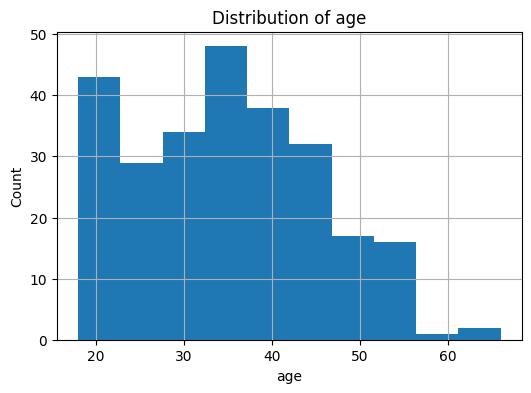

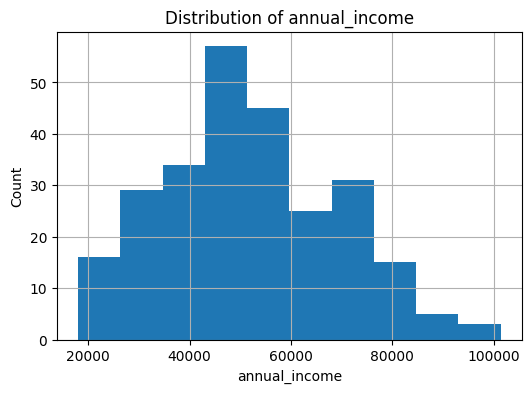

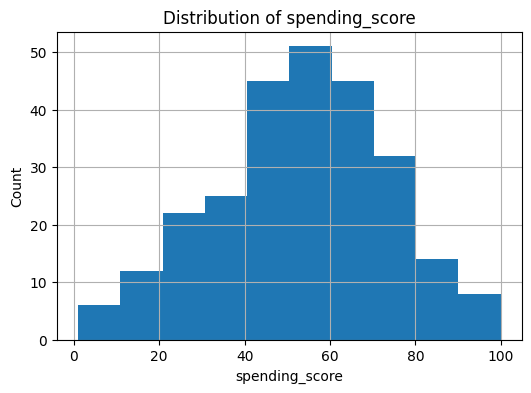

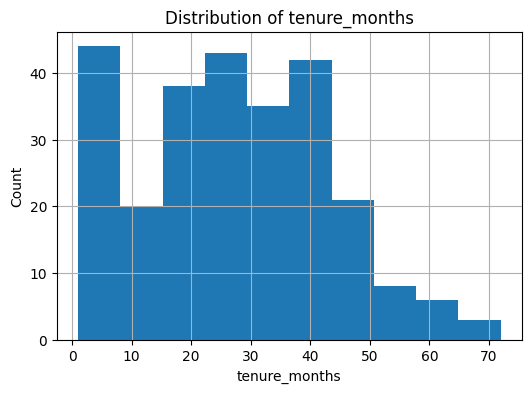

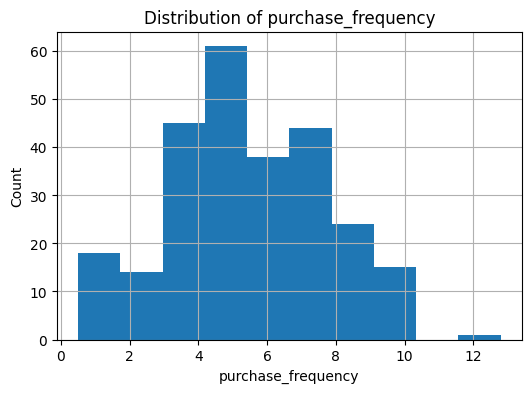

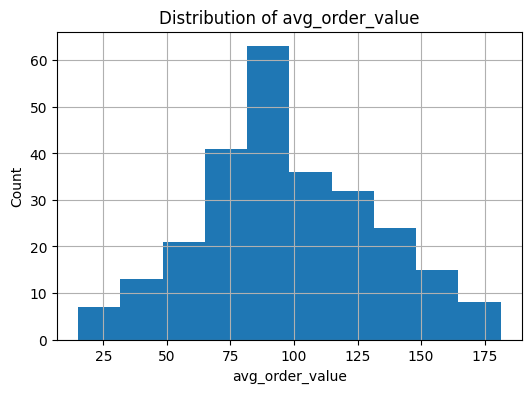

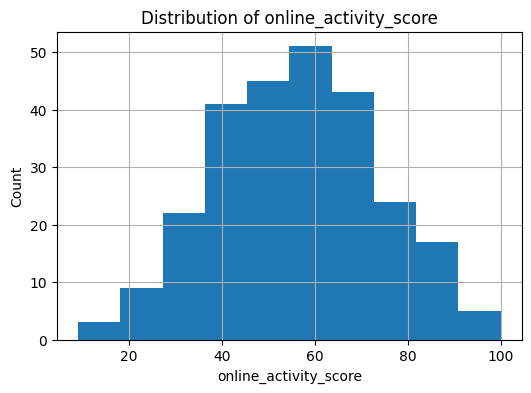

In [22]:
import matplotlib.pyplot as plt

numeric_cols = [
    "age",
    "annual_income",
    "spending_score",
    "tenure_months",
    "purchase_frequency",
    "avg_order_value",
    "online_activity_score"
]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df_clean[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

The numerical distributions suggest meaningful variation across customers, especially in **annual income**, **spending score**, **purchase frequency**, and **average order value**.  
These features are likely to be useful for identifying distinct customer segments in the clustering stage.

### Feature Selection for Clustering

In [23]:
clustering_features = df_clean[[
    "age",
    "annual_income",
    "spending_score",
    "tenure_months",
    "purchase_frequency",
    "avg_order_value",
    "online_activity_score"
]]

clustering_features.head()

,age,annual_income,spending_score,tenure_months,purchase_frequency,avg_order_value,online_activity_score
0,23.0,69952.22,61,1,3.8,157.75,9
1,30.0,43946.07,91,23,3.7,65.76,69
2,59.0,91362.15,77,32,7.0,151.65,39
3,47.0,38542.28,33,12,5.8,24.49,22
4,18.0,39402.21,75,22,5.2,121.15,40


The clustering analysis focuses on numerical customer features that describe customer behavior, value, and engagement.  
Variables such as age, annual income, spending score, tenure, purchase frequency, average order value, and online activity score were selected because they provide meaningful differences between customers and are well suited for distance-based clustering methods such as K-Means.

### Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
clustering_features_scaled = scaler.fit_transform(clustering_features)

### Choosing the Number of Clusters

To determine an appropriate number of clusters, the Elbow Method is used.  
This method compares clustering performance across different values of `k` and helps identify a point where adding more clusters provides diminishing returns.

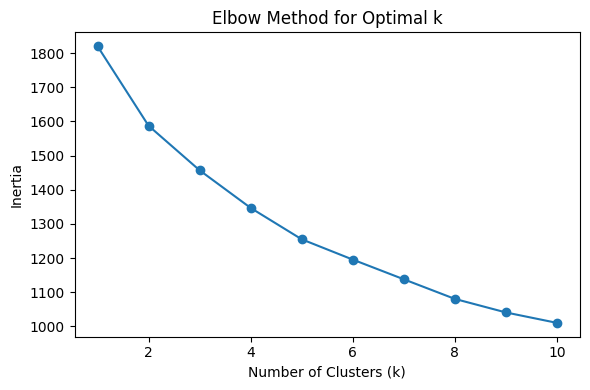

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustering_features_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("elbow_method.png")
plt.show()

### Selecting the Number of Clusters

Based on the Elbow Method, **4 clusters** were selected for the K-Means model.  
The curve shows a clear reduction in inertia up to this point, while improvements become more gradual after that.  
This suggests that 4 clusters provide a reasonable balance between simplicity and segmentation quality.

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(clustering_features_scaled)

### Cluster Size Overview

In [27]:
df_clean["cluster"].value_counts().sort_index()

,count
cluster,
0,69
1,68
2,50
3,73


The four clusters are reasonably balanced in size, which suggests that the segmentation does not produce extremely small or highly uneven customer groups.  
This makes the clusters easier to interpret and compare in the next step.

### Cluster Profile Analysis

In [28]:
cluster_summary = df_clean.groupby("cluster")[[
    "age",
    "annual_income",
    "spending_score",
    "tenure_months",
    "purchase_frequency",
    "avg_order_value",
    "online_activity_score"
]].mean().round(2)

cluster_summary

,age,annual_income,spending_score,tenure_months,purchase_frequency,avg_order_value,online_activity_score
cluster,,,,,,,
0,38.80,57136.19,43.39,13.39,4.30,71.92,53.04
1,38.31,48403.16,56.81,26.57,7.41,110.69,70.38
2,29.78,65573.18,52.30,26.76,4.37,130.54,52.70
3,30.89,41924.70,61.03,40.52,5.48,85.77,48.05


### Cluster Interpretation

The cluster profiles suggest four distinct customer segments:

- **Cluster 0 – Low-Engagement Customers:** lower spending score, lower purchase frequency, lower average order value, and shorter tenure
- **Cluster 1 – High-Engagement Active Customers:** highest purchase frequency, highest online activity, and relatively high average order value
- **Cluster 2 – High-Income Premium Customers:** highest annual income and highest average order value, suggesting a premium customer segment
- **Cluster 3 – Loyal Value-Driven Customers:** longest tenure and highest spending score despite lower average income, suggesting a loyal and valuable customer group

### Cluster Visualization

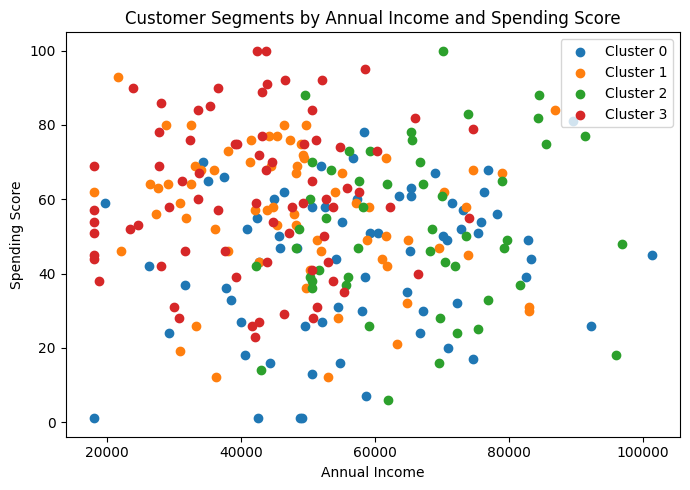

In [31]:
plt.figure(figsize=(7, 5))

for cluster in sorted(df_clean["cluster"].unique()):
    cluster_data = df_clean[df_clean["cluster"] == cluster]
    plt.scatter(
        cluster_data["annual_income"],
        cluster_data["spending_score"],
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segments by Annual Income and Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.tight_layout()
plt.savefig("customer_segments_scatter.png")
plt.show()

The scatter plot shows how customers are distributed across the four clusters based on annual income and spending score.  
Although some overlap exists between segments, the visualization still highlights meaningful differences in customer profiles.  
This is expected, since the clustering model was built using multiple features rather than only these two variables.

## Business Recommendations

Based on the cluster analysis, the company could consider the following actions:

- **Low-Engagement Customers:** target them with re-engagement campaigns, discounts, or personalized offers to increase activity and retention
- **High-Engagement Active Customers:** maintain engagement through loyalty rewards, premium recommendations, and exclusive benefits
- **High-Income Premium Customers:** focus on premium products, high-value bundles, and personalized upselling strategies
- **Loyal Value-Driven Customers:** strengthen retention through loyalty programs, long-term offers, and consistent value communication

## Conclusion

This project applied customer segmentation using data cleaning, exploratory data analysis, feature scaling, and K-Means clustering.

The analysis identified four meaningful customer groups:
- low-engagement customers
- high-engagement active customers
- high-income premium customers
- loyal value-driven customers

These segments can help a business better understand customer behavior and design more targeted marketing, retention, and product strategies.

Overall, the project demonstrates how clustering can be used to uncover hidden structure in customer data and translate it into actionable business insights.